#Used Car Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

##Loading the dataset

In [2]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/IDRA/Day12_Used_Car_Preprocessing_Dataset.csv")
df

,Car_ID,Brand,Year,Mileage_Km,Engine_CC,Power_BHP,Fuel_Type,Transmission,City,Seller_Type,Condition,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
0,CAR0001,Skoda,2021,69708,1152,128.8,Diesel,Manual,Lucknow,Individual,Good,1,0,72,6.38
1,CAR0002,Toyota,2020,88881,903,146.5,Diesel,Automatic,Chandigarh,Individual,Good,1,0,87,4.83
2,CAR0003,Volkswagen,2021,43646,1446,185.9,Diesel,Automatic,Hyderabad,Individual,Very Good,2,0,90,7.30
3,CAR0004,Tata,2019,70847,2069,148.8,Petrol,Manual,Lucknow,Individual,Excellent,3,0,66,3.82
4,CAR0005,Tata,2016,101228,1657,206.0,Petrol,Automatic,Ahmedabad,Dealer,Very Good,2,0,84,1.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,CAR0316,Mahindra,2014,151557,1186,131.9,Petrol,Automatic,Lucknow,Dealer,Fair,2,0,94,1.20
316,CAR0317,Volkswagen,2020,60512,1308,135.6,Petrol,Automatic,Delhi,Individual,Excellent,1,2,95,5.93
317,CAR0318,Mahindra,2022,76484,1038,139.6,Diesel,Automatic,Delhi,Dealer,Good,1,1,69,5.30
318,CAR0319,Hyundai,2019,125681,1327,164.3,Diesel,Automatic,Delhi,Dealer,Very Good,1,0,59,3.68


##Inspecting the dataset

In [3]:
df.shape

(320, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car_ID              320 non-null    object 
 1   Brand               320 non-null    object 
 2   Year                320 non-null    int64  
 3   Mileage_Km          320 non-null    int64  
 4   Engine_CC           320 non-null    int64  
 5   Power_BHP           320 non-null    float64
 6   Fuel_Type           320 non-null    object 
 7   Transmission        320 non-null    object 
 8   City                320 non-null    object 
 9   Seller_Type         320 non-null    object 
 10  Condition           320 non-null    object 
 11  Previous_Owners     320 non-null    int64  
 12  Accidents_Reported  320 non-null    int64  
 13  Service_Score       320 non-null    int64  
 14  Resale_Price_Lakh   320 non-null    float64
dtypes: float64(2), int64(6), object(7)
memory usage: 37.6+ KB

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns=['Car_ID'], inplace=True)
df.head()

,Brand,Year,Mileage_Km,Engine_CC,Power_BHP,Fuel_Type,Transmission,City,Seller_Type,Condition,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
0,Skoda,2021,69708,1152,128.8,Diesel,Manual,Lucknow,Individual,Good,1,0,72,6.38
1,Toyota,2020,88881,903,146.5,Diesel,Automatic,Chandigarh,Individual,Good,1,0,87,4.83
2,Volkswagen,2021,43646,1446,185.9,Diesel,Automatic,Hyderabad,Individual,Very Good,2,0,90,7.30
3,Tata,2019,70847,2069,148.8,Petrol,Manual,Lucknow,Individual,Excellent,3,0,66,3.82
4,Tata,2016,101228,1657,206.0,Petrol,Automatic,Ahmedabad,Dealer,Very Good,2,0,84,1.93


Numerical columns:
- Year
- Mileage_Km
- Engine_CC
- Power_BHP
- Previous_Owners
- Accidents_Reported
- Service_Score
- Resale_Price_Lakh


Categorical columns:
- Brand
- Fuel_Type
- Transmission
- City
- Seller_Type
- Condition

In [8]:
num_col = ['Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP', 'Previous_Owners', 'Accidents_Reported', 'Service_Score', 'Resale_Price_Lakh']
cat_col = ['Brand', 'Fuel_Type', 'Transmission', 'City', 'Seller_Type', 'Condition']

In [9]:
df[num_col].describe()

,Year,Mileage_Km,Engine_CC,Power_BHP,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,2019.537500,74110.203125,1346.703125,150.489688,1.668750,0.243750,76.203125,4.963031
std,3.341367,38885.260771,543.408160,36.665353,0.865369,0.528164,12.745864,3.359259
min,2014.000000,700.000000,600.000000,51.400000,1.000000,0.000000,55.000000,1.200000
25%,2017.000000,46323.250000,1004.750000,128.450000,1.000000,0.000000,64.750000,2.277500
50%,2020.000000,72718.500000,1303.000000,150.750000,1.000000,0.000000,77.000000,4.610000
75%,2022.000000,97951.500000,1635.250000,171.475000,2.000000,0.000000,87.000000,6.835000
max,2025.000000,320000.000000,5000.000000,390.000000,4.000000,2.000000,98.000000,28.500000


##Outliers detection and cleanup

In [10]:
for col in num_col:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  low_bound = q1 - 1.5 * iqr
  high_bound = q3 + 1.5 * iqr

  if col in ['Mileage_Km', 'Engine_CC', 'Power_BHP', 'Resale_Price_Lakh']:
    print(f"\nOutliers in {col}:")
    print(df[(df[col] < low_bound) | (df[col] > high_bound)][col])
    print(f"Low: {low_bound}\nHigh: {high_bound}")


Outliers in Mileage_Km:
31    320000
67    280000
Name: Mileage_Km, dtype: int64
Low: -31119.125
High: 175393.875

Outliers in Engine_CC:
31     5000
67     4200
149    4200
188    3800
286    3100
298    2596
Name: Engine_CC, dtype: int64
Low: 59.0
High: 2581.0

Outliers in Power_BHP:
84      56.7
119     54.1
149    390.0
169     60.8
188    350.0
213    245.0
236     51.4
Name: Power_BHP, dtype: float64
Low: 63.91249999999998
High: 236.0125

Outliers in Resale_Price_Lakh:
31     15.0
149    22.5
188    18.7
227    28.5
261    16.9
Name: Resale_Price_Lakh, dtype: float64
Low: -4.55875
High: 13.67125


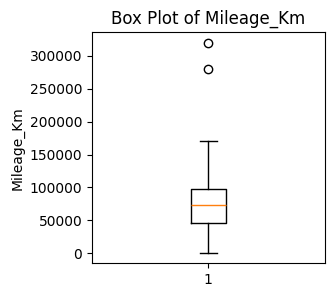

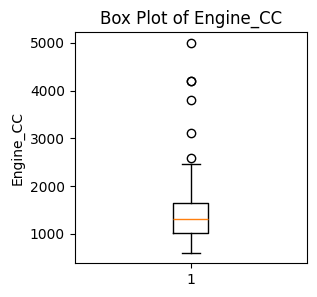

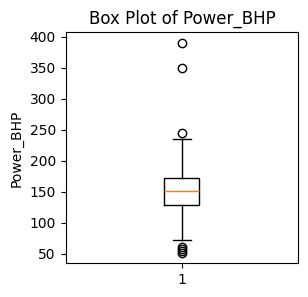

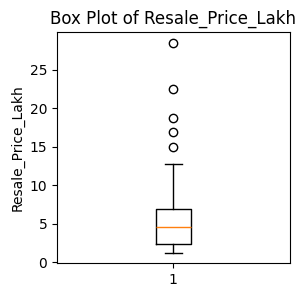

In [11]:
import matplotlib.pyplot as plt
for col in ['Mileage_Km', 'Engine_CC', 'Power_BHP', 'Resale_Price_Lakh']:
  plt.figure(figsize=(3,3))
  plt.boxplot(df[col])
  plt.title(f'Box Plot of {col}')
  plt.ylabel(col)
  plt.show()

After inspecting the mathematical and graphical representations of the IQR, contents of row 31 are suspicious. So after checking its content, the row will be deleted.

In [12]:
df.loc[31]

,31
Brand,Volkswagen
Year,2025
Mileage_Km,320000
Engine_CC,5000
Power_BHP,85.0
Fuel_Type,Petrol
Transmission,Automatic
City,Lucknow
Seller_Type,Certified Dealer
Condition,Excellent


In [13]:
df = df.drop(index=31).reset_index(drop=True)
df.loc[31]

,31
Brand,Volkswagen
Year,2020
Mileage_Km,53877
Engine_CC,1673
Power_BHP,163.2
Fuel_Type,Petrol
Transmission,Manual
City,Ahmedabad
Seller_Type,Certified Dealer
Condition,Good


##Split into training (x) and test (y) sections

In [14]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##Encoding

In [16]:
num = ['Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP', 'Service_Score']
discrete = ['Previous_Owners', 'Accidents_Reported']

nominal = ['Brand', 'Fuel_Type', 'Transmission', 'City', 'Seller_Type']
ordinal = ['Condition']

In [17]:
print(df['Condition'].unique())

['Good' 'Very Good' 'Excellent' 'Fair' 'Poor']


In [18]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
one_encoder = OneHotEncoder()
one_encoder.fit(x_train[nominal])
nominal_train = one_encoder.transform(x_train[nominal])
nominal_test = one_encoder.transform(x_test[nominal])

ordinal_encoder = OrdinalEncoder(categories=[['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']])
ordinal_encoder.fit(x_train[ordinal])
ordinal_train = ordinal_encoder.transform(x_train[ordinal])
ordinal_test = ordinal_encoder.transform(x_test[ordinal])

##Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler_num = [
    'Year',
    'Mileage_Km',
    'Engine_CC',
    'Power_BHP',
    'Service_Score',
    'Previous_Owners',
    'Accidents_Reported'
]

scaler = StandardScaler()
scaler.fit(x_train[scaler_num])
x_train[scaler_num] = scaler.transform(x_train[scaler_num])
x_test[scaler_num] = scaler.transform(x_test[scaler_num])

In [20]:
x_train[scaler_num].head()

,Year,Mileage_Km,Engine_CC,Power_BHP,Service_Score,Previous_Owners,Accidents_Reported
210,1.296220,-1.491270,0.799084,1.567827,0.316372,0.430063,-0.455249
76,-0.848129,-0.179350,-0.877057,0.542385,-1.624794,2.763383,-0.455249
94,0.989884,0.221392,-0.514751,-0.359161,1.325778,-0.736597,-0.455249
222,-1.767136,1.814738,0.230836,0.908803,1.636365,-0.736597,1.447842
311,0.989884,-0.139036,0.402455,0.320953,0.161079,0.430063,-0.455249


In [21]:
print(x_train[scaler_num].mean())
print(x_train[scaler_num].std())

Year                  5.210647e-15
Mileage_Km           -7.488563e-17
Engine_CC            -9.055937e-17
Power_BHP             7.453733e-16
Service_Score         2.577459e-16
Previous_Owners       5.572884e-17
Accidents_Reported    6.966105e-18
dtype: float64
Year                  1.001967
Mileage_Km            1.001967
Engine_CC             1.001967
Power_BHP             1.001967
Service_Score         1.001967
Previous_Owners       1.001967
Accidents_Reported    1.001967
dtype: float64


In [22]:
x_test[scaler_num].head()

,Year,Mileage_Km,Engine_CC,Power_BHP,Service_Score,Previous_Owners,Accidents_Reported
73,-1.767136,1.701103,1.809727,1.797168,0.394019,-0.736597,-0.455249
218,1.602555,-1.046298,0.736158,0.647829,-1.081267,2.763383,-0.455249
25,-1.154465,0.744290,-1.222201,-0.622770,1.481071,-0.736597,-0.455249
208,-1.767136,1.072484,0.499705,-0.153545,-0.925974,0.430063,-0.455249
9,-1.460800,2.143125,-0.011337,0.057343,-0.770681,-0.736597,-0.455249


In [23]:
print(x_test[scaler_num].mean())
print(x_test[scaler_num].std())

Year                 -0.379053
Mileage_Km            0.258009
Engine_CC            -0.025608
Power_BHP            -0.056462
Service_Score        -0.301161
Previous_Owners       0.211314
Accidents_Reported   -0.009212
dtype: float64
Year                  1.047002
Mileage_Km            0.993922
Engine_CC             0.784820
Power_BHP             0.795360
Service_Score         0.898764
Previous_Owners       1.036742
Accidents_Reported    0.943487
dtype: float64


Numerical features arescaled using StandardScaler. The training set features have approximately zero mean and one standard deviation

##Combining the subsets & verifying the dataset

In [24]:
nominal_cols = one_encoder.get_feature_names_out(nominal)

nominal_train_df = pd.DataFrame(nominal_train.toarray(), columns=nominal_cols, index=x_train.index)
nominal_test_df = pd.DataFrame(nominal_test.toarray(), columns=nominal_cols, index=x_test.index)

ordinal_train_df = pd.DataFrame(ordinal_train, columns=ordinal, index=x_train.index)
ordinal_test_df = pd.DataFrame(ordinal_test, columns=ordinal, index=x_test.index)

In [25]:
processed_x_train = pd.concat([x_train[scaler_num], ordinal_train_df, nominal_train_df], axis=1)
processed_x_train.head()

,Year,Mileage_Km,Engine_CC,Power_BHP,Service_Score,Previous_Owners,Accidents_Reported,Condition,Brand_Honda,Brand_Hyundai,...,City_Delhi,City_Hyderabad,City_Jaipur,City_Kochi,City_Lucknow,City_Mumbai,City_Pune,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual
210,1.296220,-1.491270,0.799084,1.567827,0.316372,0.430063,-0.455249,3.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
76,-0.848129,-0.179350,-0.877057,0.542385,-1.624794,2.763383,-0.455249,2.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
94,0.989884,0.221392,-0.514751,-0.359161,1.325778,-0.736597,-0.455249,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
222,-1.767136,1.814738,0.230836,0.908803,1.636365,-0.736597,1.447842,3.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
311,0.989884,-0.139036,0.402455,0.320953,0.161079,0.430063,-0.455249,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [26]:
processed_x_test = pd.concat([x_test[scaler_num], ordinal_test_df, nominal_test_df], axis=1)
processed_x_test.head()

,Year,Mileage_Km,Engine_CC,Power_BHP,Service_Score,Previous_Owners,Accidents_Reported,Condition,Brand_Honda,Brand_Hyundai,...,City_Delhi,City_Hyderabad,City_Jaipur,City_Kochi,City_Lucknow,City_Mumbai,City_Pune,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual
73,-1.767136,1.701103,1.809727,1.797168,0.394019,-0.736597,-0.455249,2.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
218,1.602555,-1.046298,0.736158,0.647829,-1.081267,2.763383,-0.455249,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
25,-1.154465,0.744290,-1.222201,-0.622770,1.481071,-0.736597,-0.455249,2.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
208,-1.767136,1.072484,0.499705,-0.153545,-0.925974,0.430063,-0.455249,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
9,-1.460800,2.143125,-0.011337,0.057343,-0.770681,-0.736597,-0.455249,3.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [27]:
processed_x_train.reset_index(drop=True, inplace=True)
processed_x_test.reset_index(drop=True, inplace=True)

In [28]:
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [29]:
processed_train = pd.concat([processed_x_train, y_train], axis=1)
processed_test = pd.concat([processed_x_test, y_test], axis=1)

In [30]:
print("Training set shape:", processed_train.shape)
print("Testing set shape:", processed_test.shape)

Training set shape: (255, 38)
Testing set shape: (64, 38)


In [31]:
print("Training null values: ", processed_train.isnull().sum().sum())
print("Testing null values: ", processed_test.isnull().sum().sum())

Training null values:  0
Testing null values:  0


In [32]:
print("Training duplicates:", processed_train.duplicated().sum())
print("Testing duplicates:", processed_test.duplicated().sum())

Training duplicates: 0
Testing duplicates: 0


In [33]:
processed_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          255 non-null    float64
 1   Mileage_Km                    255 non-null    float64
 2   Engine_CC                     255 non-null    float64
 3   Power_BHP                     255 non-null    float64
 4   Service_Score                 255 non-null    float64
 5   Previous_Owners               255 non-null    float64
 6   Accidents_Reported            255 non-null    float64
 7   Condition                     255 non-null    float64
 8   Brand_Honda                   255 non-null    float64
 9   Brand_Hyundai                 255 non-null    float64
 10  Brand_Kia                     255 non-null    float64
 11  Brand_Mahindra                255 non-null    float64
 12  Brand_Maruti                  255 non-null    float64
 13  Brand

In [34]:
processed_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          64 non-null     float64
 1   Mileage_Km                    64 non-null     float64
 2   Engine_CC                     64 non-null     float64
 3   Power_BHP                     64 non-null     float64
 4   Service_Score                 64 non-null     float64
 5   Previous_Owners               64 non-null     float64
 6   Accidents_Reported            64 non-null     float64
 7   Condition                     64 non-null     float64
 8   Brand_Honda                   64 non-null     float64
 9   Brand_Hyundai                 64 non-null     float64
 10  Brand_Kia                     64 non-null     float64
 11  Brand_Mahindra                64 non-null     float64
 12  Brand_Maruti                  64 non-null     float64
 13  Brand_R

In [35]:
processed_train['Resale_Price_Lakh'].describe()

,Resale_Price_Lakh
count,255.000000
mean,5.090275
std,3.349726
min,1.200000
25%,2.670000
50%,4.830000
75%,6.980000
max,28.500000


In [36]:
print("Number of features before encoding:", x_train.shape[1])
print("Number of features after preprocessing:", processed_x_train.shape[1])

Number of features before encoding: 13
Number of features after preprocessing: 37


No. of features are increased as one-hot encoding created multiple columns from each categorical feature

In [37]:
print('Car_ID' in processed_train.columns)

False


In [38]:
processed_train.to_csv(r"/content/drive/MyDrive/Colab Notebooks/IDRA/Day12_used_car_train_processed.csv", index=False)
processed_test.to_csv(r"/content/drive/MyDrive/Colab Notebooks/IDRA/Day12_used_car_test_processed.csv", index=False)

In [39]:
processed_full = pd.concat([processed_train, processed_test], ignore_index=True)
processed_full.to_csv(r"/content/drive/MyDrive/Colab Notebooks/IDRA/Day12_used_car_full_processed.csv", index=False)

In [40]:
processed_full.shape

(319, 38)

In [41]:
processed_full.head()

,Year,Mileage_Km,Engine_CC,Power_BHP,Service_Score,Previous_Owners,Accidents_Reported,Condition,Brand_Honda,Brand_Hyundai,...,City_Hyderabad,City_Jaipur,City_Kochi,City_Lucknow,City_Mumbai,City_Pune,Seller_Type_Certified Dealer,Seller_Type_Dealer,Seller_Type_Individual,Resale_Price_Lakh
0,1.296220,-1.491270,0.799084,1.567827,0.316372,0.430063,-0.455249,3.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,10.40
1,-0.848129,-0.179350,-0.877057,0.542385,-1.624794,2.763383,-0.455249,2.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.28
2,0.989884,0.221392,-0.514751,-0.359161,1.325778,-0.736597,-0.455249,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.49
3,-1.767136,1.814738,0.230836,0.908803,1.636365,-0.736597,1.447842,3.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.40
4,0.989884,-0.139036,0.402455,0.320953,0.161079,0.430063,-0.455249,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,7.09


##Insights
- Since there is no null values or duplicate values, no need for further processing
- Dropped colummn Car_ID as it is not necessary for the training
- The columns are divided into numerical and categorical columns
- The numerical columns are then checked for outliers using IQR and box plots
- Since after checking the contents of row 31 and finding them suspicious, the row 31 is deleted
- Encoded the training and test sets separately using one hot encoding and ordinal encoding
- Ensured that preprocessing transformations are fitted only on the training data to avoid data leakage.
- Standardized the numerical features using StandardScaler
- Trained data  only fitted to the scaler and test data  transformed also
- Verified the processed training, testing and full datasets for correct dimensions, null values and duplicated values
- Exported the processed datasets to csv files